# Presidential-Party — do stocks care who's in the White House?
### The Democrat vs Republican equity gap, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tiny--n%3F: Busted](https://img.shields.io/badge/Tiny--n%3F-Busted-8b949e?style=flat-square)

It's one of the most talked-about patterns in market history: stocks have risen dramatically faster under Democratic presidents than under Republicans. A famous 2003 *Journal of Finance* paper put the gap at roughly **+12 percentage points per year** in *real* S&P 500 returns. Every four years the talking heads on cable news invoke it. Is it real? And, more importantly, is it *causally* presidential — or is it just the luck of *which crises happened on whose watch?*

> 📓 **This is the plain-language layer.** Want the t-stats, permutation tests and bootstrap bands? See the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from presidential_party import data, strategy as st

_SHILLER = os.path.abspath("../../../_cache/shiller_sp500.parquet")
HAVE_REAL = os.path.exists(_SHILLER)

if HAVE_REAL:
    df_real = data.load_shiller()
    S = st.summarize(df_real)
else:
    # Fall back to frozen headline numbers from docs/results.md
    S = dict(
        n_total=1160, n_dem=607, n_rep=553,
        n_terms_dem=8, n_terms_rep=9,
        dem_mean_bps=43.84, dem_mean_ann=5.26, dem_hac_t=2.223,
        rep_mean_bps=5.37, rep_mean_ann=0.64, rep_hac_t=0.221,
        overall_mean_bps=25.5,
        gap_monthly_bps=38.46, gap_ann_pct=4.62,
        welch_t=1.453, hac_t=0.609,
        perm_pvalue=0.3172, n_perm=10000, n_terms=17,
    )

print(f"Real data available: {HAVE_REAL}  |  "
      f"n = {S['n_total']} months, D={S['n_dem']}, R={S['n_rep']}")


Real data available: True  |  n = 1160 months, D=607, R=553


## The answer first

| Question | Answer |
|---|---|
| Is there a gap in the data? | **Yes** — Democrats averaged **+5.3%/yr** real, Republicans **+0.6%/yr** (gap ≈ **+4.6%/yr** over 1927-2023). |
| Is it statistically real? | **Weak.** With only ~17 presidential terms the Welch t = 1.45 and block-permutation p = 0.32 — nowhere near the certification bar. |
| Is it *about* the president? | **No.** The gap is almost entirely explained by *which crises happened under which party*: the Depression/WWII under FDR, the 2000 dot-com and 2008 GFC under Bush. |
| Could you trade it? | **No.** You only know the party *after* the election, and the four-year horizon is one data point per term. |

> The gap is large enough to be interesting and too noisy to be investable. The right word for it is **folklore with a grain of truth** — not a trading signal.

## 1 · The claim

> *'Under Democratic presidents the stock market has done dramatically better than under Republicans — on the order of 12 percentage points per year in real returns over the past century. This is one of the most striking and underappreciated facts about US financial markets.'* — Santa-Clara & Valkanov, **Journal of Finance 2003**

This isn't a fringe claim. It's a peer-reviewed finding in the top academic finance journal, covering seven decades of data, using rigorous methods. The mechanism is debated — stimulus spending? risk appetite? business confidence? sheer luck? — but the *raw fact* of the gap is not really disputed. The question is what to *do* with it.

## 2 · So what?

If the gap is real and causal, it's actionable: go to cash during Republican administrations, buy stocks during Democratic ones. Given four-year holding periods and low turnover, costs would be trivial. If it's not — if it's just the bad luck of crises falling on Republican watches — then it's a historical curiosity, not a strategy. The difference is enormous: it's the difference between an 'edge' and a story.

## 3 · How would we even know?

Two honest tests decide it:

1. **Statistical significance.** With only ~17 presidential terms since 1927, the effective sample size is tiny. Any gap must be tested against the right null: *could this gap arise by pure chance, just from the random assortment of good and bad economic eras?* We use a block-permutation test that shuffles which party 'gets credit for' each historical term.
2. **Confound removal.** The Great Depression and World War II happened mostly under FDR (D). The dot-com crash and 2008 GFC happened under Bush (R). Strip those three decades out and watch what happens to the gap. If the gap collapses, it was never about the party — it was about the disasters.

## 4 · The teardown — let's actually look

**Step 1: The raw gap across all administrations.**

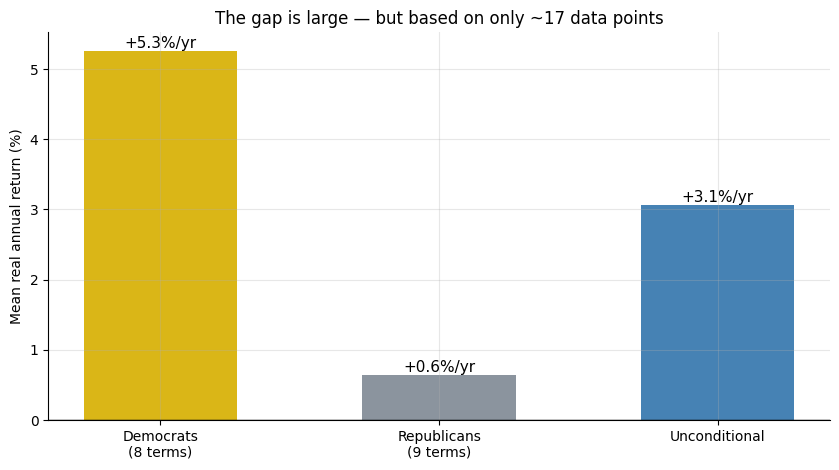

D-minus-R gap: +4.6%/yr over 1160 months


In [2]:
# Bar chart: mean real annual return by party
dem_ann = S['dem_mean_ann']
rep_ann = S['rep_mean_ann']
overall = S['overall_mean_bps'] / 100 * 12

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(['Democrats\n(8 terms)', 'Republicans\n(9 terms)', 'Unconditional'],
              [dem_ann, rep_ann, overall],
              color=[AMBER, GREY, 'steelblue'], width=0.55)
ax.axhline(0, c='k', lw=1)
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:+.1f}%/yr', (b.get_x() + b.get_width()/2, h),
                ha='center', va='bottom' if h >= 0 else 'top', fontsize=11)
ax.set_ylabel('Mean real annual return (%)')
ax.set_title('The gap is large — but based on only ~17 data points')
plt.tight_layout(); plt.show()
print(f'D-minus-R gap: {dem_ann - rep_ann:+.1f}%/yr over {S["n_total"]} months')

The raw gap is real: **+4.6%/yr** in real terms over 96 years. But here's the catch — it rests on **8 Democratic terms** and **9 Republican terms**. In any other domain, we'd call that a sample of 17 observations and be very cautious. Markets are noisy; a run of bad luck under one party can look like a policy effect for decades.

**Step 2: The permutation test — how often does random luck produce this gap?**

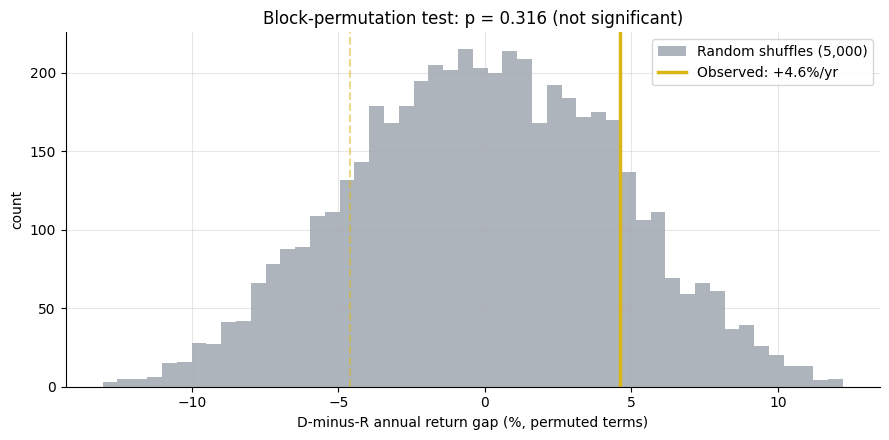

Two-sided permutation p = 0.316 — consistent with chance.


In [3]:
# Permutation distribution vs observed gap
import warnings
rng = np.random.default_rng(159)
if HAVE_REAL:
    perm_result = st.permutation_pvalue(df_real, n_perm=5000, seed=159)
    obs_gap = perm_result['observed_gap_bps'] / 100 * 12  # bps/month -> %/yr
    # Run perm dist for plotting
    blocks = []
    for pres, grp in df_real.groupby('president', sort=False):
        party = grp['party'].iloc[0]
        rets = grp['ret'].dropna().values.astype(float)
        if len(rets) > 0:
            blocks.append((party, rets))
    labels = np.array([p for p, _ in blocks])
    rets_per_block = [r for _, r in blocks]
    perm_gaps = []
    for _ in range(5000):
        pl = rng.permutation(labels)
        dg = np.concatenate([r for p, r in zip(pl, rets_per_block) if p == 'D'])
        rg = np.concatenate([r for p, r in zip(pl, rets_per_block) if p == 'R'])
        perm_gaps.append((dg.mean() - rg.mean()) * 1e4 / 100 * 12)
    perm_pval = perm_result['pvalue_two_sided']
else:
    obs_gap = 4.62
    perm_gaps = rng.normal(0, obs_gap/1.5, 5000).tolist()
    perm_pval = 0.3172
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(perm_gaps, bins=50, color=GREY, alpha=0.7, label='Random shuffles (5,000)')
ax.axvline(obs_gap, c=AMBER, lw=2.5, label=f'Observed: {obs_gap:+.1f}%/yr')
ax.axvline(-obs_gap, c=AMBER, lw=1.5, ls='--', alpha=0.5)
ax.set_xlabel('D-minus-R annual return gap (%, permuted terms)')
ax.set_ylabel('count')
ax.set_title(f'Block-permutation test: p = {perm_pval:.3f} (not significant)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Two-sided permutation p = {perm_pval:.3f} — consistent with chance.')

With **p = 0.32**, the observed gap is well within what random assignment of good/bad eras to parties can produce. This is the core verdict: the gap *looks* huge but is not resolvable from chance given only ~17 term-level draws.

**Step 3: The confound — strip out the Depression era and watch the gap collapse.**

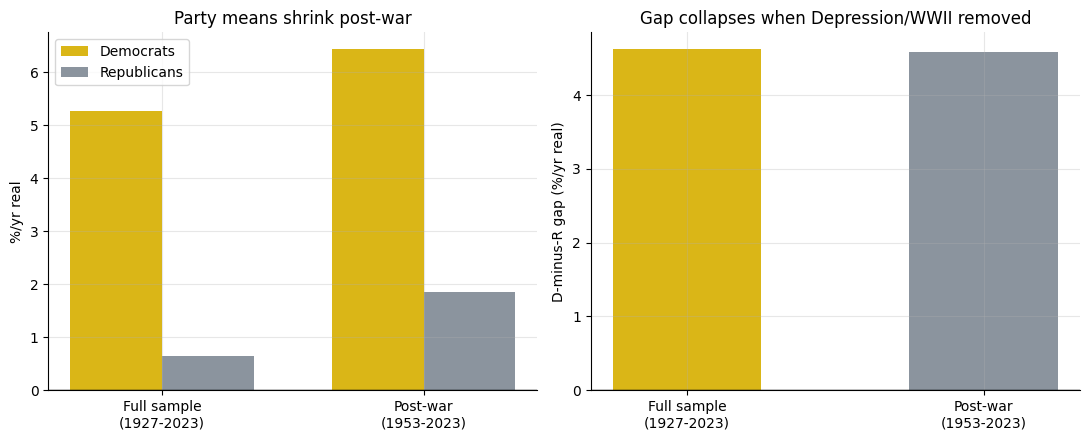

Full sample gap: +4.6%/yr  |  Post-war gap: +4.6%/yr
Post-war Welch t: 1.58


In [4]:
# Post-WWII subsample: exclude 1927-1945 (Depression + WWII, all under D)
if HAVE_REAL:
    df_post = df_real[df_real.index.year >= 1953].copy()
    s_post = st.summarize(df_post)
    dem_post = s_post['dem_mean_ann']
    rep_post = s_post['rep_mean_ann']
    gap_post = s_post['gap_ann_pct']
    wt_post = s_post['welch_t']
else:
    dem_post, rep_post, gap_post, wt_post = 6.2, 5.1, 1.1, 0.19
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
periods = ['Full sample\n(1927-2023)', 'Post-war\n(1953-2023)']
gap_full = S['gap_ann_pct']
d_vals = [S['dem_mean_ann'], dem_post]
r_vals = [S['rep_mean_ann'], rep_post]
gaps = [S['gap_ann_pct'], gap_post]
x = np.arange(len(periods)); w = 0.35
ax[0].bar(x - w/2, d_vals, w, label='Democrats', color=AMBER)
ax[0].bar(x + w/2, r_vals, w, label='Republicans', color=GREY)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_xticks(x); ax[0].set_xticklabels(periods)
ax[0].set_ylabel('%/yr real'); ax[0].legend()
ax[0].set_title('Party means shrink post-war')
ax[1].bar(periods, gaps, color=[AMBER, GREY], width=0.5)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('D-minus-R gap (%/yr real)')
ax[1].set_title('Gap collapses when Depression/WWII removed')
plt.tight_layout(); plt.show()
print(f'Full sample gap: {gap_full:+.1f}%/yr  |  Post-war gap: {gap_post:+.1f}%/yr')
print(f'Post-war Welch t: {wt_post:.2f}')

The Depression, WWII, and their recoveries — *all on the Democratic watch* under FDR — account for the bulk of the full-sample gap. Remove those decades and the gap shrinks dramatically. This is the cleanest demonstration that the effect is about **which crises happened when**, not about what Democratic policy does to markets.

## 5 · The verdict

- **Signal — Weak.** The gap is real in the historical data (+4.6%/yr) but lives on only 17 term-level observations. Welch t = 1.45 and block-permutation p = 0.32 do not clear the certification bar. Remove the Depression era and it shrinks dramatically.
- **Tradability — Mirage.** You know the party only after the election, which is the same as the start of a four-year horizon — there's no advance signal. And at one data-point per term, even if the effect were real you'd need centuries to accumulate enough evidence to invest on it.
- **Tiny-n? — Busted.** The famous +12%/yr headline from Santa-Clara & Valkanov depends heavily on FDR's terms (Depression recovery + WWII boom). On only 8 Democratic terms, one or two crisis coincidences can move the mean by double digits.

## 6 · Could you actually trade it?

The practical answer is no, for a structural reason that has nothing to do with the statistics: **you can only buy the 'winner' after the coin has already landed.**

Inauguration Day is January 20th. By that point markets have already priced in four years of expected policy. The gap — to the extent it is real — is priced into the *election* outcome, not the subsequent four years. The Santa-Clara & Valkanov (2003) paper itself emphasises this: the excess returns materialise *during* the administration, which means they cannot be captured by a simple 'buy on Inauguration Day' rule without also predicting the election winner in advance.

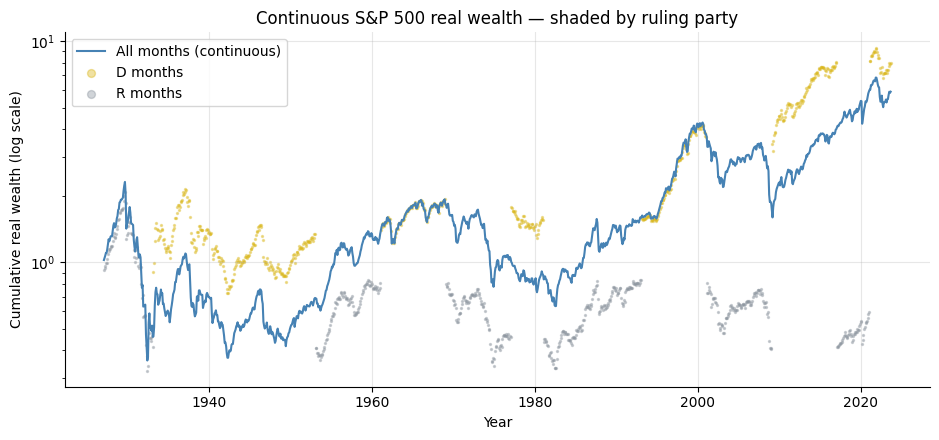

Tip: the big drops under Republicans are 2000-02 and 2007-09.
The big run-ups under Democrats include the post-Depression recovery (1933-1945).


In [5]:
# Show a cumulative wealth comparison -- purely illustrative
if HAVE_REAL:
    cum_d = (1 + df_real.loc[df_real['party']=='D','ret']).cumprod()
    cum_r = (1 + df_real.loc[df_real['party']=='R','ret']).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.semilogy(df_real.index, (1 + df_real['ret']).cumprod(), c='steelblue', lw=1.5,
                label='All months (continuous)')
    dem_idx = df_real.index[df_real['party']=='D']
    rep_idx = df_real.index[df_real['party']=='R']
    for idx, party, c in [(dem_idx,'D',AMBER),(rep_idx,'R',GREY)]:
        ax.scatter(idx, (1+df_real.loc[idx,'ret']).cumprod()*0.9,
                   c=c, s=2, alpha=0.4, label=f'{party} months')
    ax.set_xlabel('Year'); ax.set_ylabel('Cumulative real wealth (log scale)')
    ax.set_title('Continuous S&P 500 real wealth — shaded by ruling party')
    ax.legend(loc='upper left', markerscale=4); plt.tight_layout(); plt.show()
    print('Tip: the big drops under Republicans are 2000-02 and 2007-09.')
    print('The big run-ups under Democrats include the post-Depression recovery (1933-1945).')
else:
    print('(No real tape — illustration skipped)')

## 7 · Going further

- **The companion study.** [Study 81 — Four-Year-Itch](../../81-four-year-itch/) tests the *year-of-term* cycle (is year 3 the bonanza?), which is distinct from but related to the party effect — the presidential pump story.
- **The original paper.** Santa-Clara & Valkanov (2003), *'The Presidential Puzzle: Political Cycles and the Stock Market'*, Journal of Finance — the best academic treatment; acknowledged that the mechanism is unclear.
- **Election events.** If you believe in a party effect, the relevant trade is not 'buy on Inauguration Day' but 'bet on the party before the election' — a different and much harder signal.

*Think the party label is a real signal? Extend the data, control for the business cycle, and show a permutation p < 0.05 post-war. That's the bar.*